# ОБУЧЕНИЕ СЕМАНТИЧЕСКОЙ СЕГМЕНТАЦИИ 

Структура:
- Validation, Validationannot - изображения и маски из валидационного сета в формате Camvid 1.0
- Train, Trainannot - соответственно из трейн сета

Доп файлы:
- label_colors.txt - цвета классов масок сегментаций из трейн и тест сета в формате Camvid 1.0

In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader
from torch.utils.data import Dataset as BaseDataset
import os
#import torch_tensorrt
import random 
import segmentation_models_pytorch as smp
from segmentation_models_pytorch import utils
import albumentations as albu
from torch.amp import autocast, GradScaler
from tqdm import tqdm
%matplotlib inline

In [2]:
print(torch.cuda.is_available())

True


In [3]:
seed = 40
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
np.random.seed(seed)
random.seed(seed)
torch.backends.cudnn.benchmark = False
torch.backends.cudnn.deterministic = True

# Параметры

In [4]:
DATSET_NAME = "car_dataset"

X_TRAIN_DIR = f"{DATSET_NAME}/images/train"
Y_TRAIN_DIR = f"{DATSET_NAME}/annotations/train_masks_rgb"

X_VALID_DIR = f"{DATSET_NAME}/images/val"
Y_VALID_DIR = f"{DATSET_NAME}/annotations/val_masks_rgb"

X_TEST_DIR = f"{DATSET_NAME}/images/test"
Y_TEST_DIR = f"{DATSET_NAME}/annotations/test_masks_rgb"

LABEL_COLORS_FILE = f"{DATSET_NAME}/U-Net_data.txt" #Пример: 0 0 0 human \n 255 40 40 car

Задание констант:

In [5]:
CLASSES = [
        "background", "back_bumper", "back_door", "back_glass", "back_left_door", "back_left_light", 
    "back_light", "back_right_door", "back_right_light", "front_bumper", "front_door", "front_glass", 
    "front_left_door", "front_left_light", "front_light", "front_right_door", "front_right_light", 
    "hood", "left_mirror", "right_mirror", "object", "tailgate", "trunk", "wheel"
]

COLORS_IMSHOW = {
        "background" : np.array([0, 0, 0]),
        "back_bumper" : np.array([0, 0, 255]),
        "back_door" : np.array([0, 255, 0]),
        "back_glass" : np.array([255, 0, 0]),
        "back_left_door" : np.array([0, 255, 255]),
        "back_left_light" : np.array([255, 0, 255]),
        "back_light" : np.array([255, 255, 0]),
        "back_right_door" : np.array([0, 128, 255]),
        "back_right_light" : np.array([255, 0, 128]),
        "front_bumper" : np.array([128, 255, 0]),
        "front_door" : np.array([128, 0, 255]),
        "front_glass" : np.array([0, 255, 128]),
        "front_left_door" : np.array([255, 128, 0]),
        "front_left_light" : np.array([128, 128, 255]),
        "front_light" : np.array([128, 255, 128]),
        "front_right_door" : np.array([255, 128, 128]),
        "front_right_light" : np.array([128, 255, 255]),
        "hood" : np.array([255, 128, 255]),
        "left_mirror" : np.array([255, 255, 128]),
        "right_mirror" : np.array([0, 64, 192]),
        "object" : np.array([192, 0, 64]),
        "tailgate" : np.array([64, 192, 0]),
        "trunk" : np.array([64, 0, 192]),
        "wheel" : np.array([0, 192, 64]),
}


#ENCODER = 'resnet18'
ENCODER = "timm-efficientnet-b8"#'efficientnet-b4'#"timm-resnest50d"#resnet34'
ENCODER_WEIGHTS = 'imagenet'
ACTIVATION = 'softmax2d'
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

EPOCHS = 40
BATCH_SIZE = 4

INIT_LR = 0.0001
LR_DECREASE_STEP = 15
LR_DECREASE_COEF = 2 # LR будет разделен на этот коэф раз в LR_DECREASE_STEP эпох

INFER_WIDTH = 640
INFER_HEIGHT = 640

loss = utils.losses.DiceLoss()

# Вспомогательные функции

В данном примере в датасете на входе имеется трехканальная (так как 3 класса) фотка где в кажом пикселе стоит во всех каналах 0 кроме одного в котором 1. Тем самым кодируется класс конкретного пикселя в маске

In [6]:
def create_annotations_of_no_calsses_images(images_folder, annotations_folder):
    image_files = os.listdir(images_folder)
    for image_file in image_files:
        image_path = os.path.join(images_folder, image_file)
        annotation_path = os.path.join(annotations_folder, f"{os.path.splitext(image_file)[0]}.png")        
        img = Image.open(image_path)
        width, height = img.size
        
        if not os.path.exists(annotation_path):
            img = Image.new('RGB', (width, height), color='black')
            img.save(annotation_path)

def _convert_multichannel2singlechannel(mc_mask: np.ndarray):
    """ Осуществляет перевод трехканальной маски (число каналов сколько классов) в трехканальное 
    изображение где будет расцветка как зададим в словаре colors_imshow для классов """

    # colors_imshow = {
    #         "background" : np.array([255, 255, 255]),
    #         "human" : np.array([0, 0, 0])
    # }

    sc_mask = np.zeros((mc_mask[0].shape[0], mc_mask[0].shape[1], 3), dtype=np.uint8)
    square_ratios = {}

    for i, singlechannel_mask in enumerate(mc_mask):


        
#Сюда нам нужно подать маску из двух слоев (не (R, G, B), а (background, human))


        
        cls = CLASSES[i]
        singlechannel_mask = singlechannel_mask.squeeze()

        # Заодно осуществляет подсчет процента каждого класса (сумма пикселей на общее число)
        square_ratios[cls] = singlechannel_mask.sum() / singlechannel_mask.size
        
        sc_mask += np.multiply.outer(singlechannel_mask > 0, COLORS_IMSHOW[cls]).astype(np.uint8)
        

    title = "Площади: " + "\n".join([f"{cls}: {square_ratios[cls]*100:.1f}%" for cls in CLASSES])
    return sc_mask, title

def visualize_with_image(image, mc_mask, color, class_id):
    #mc_mask = mc_mask.transpose(2, 0, 1)
    result = image
    for class_id in range(0, len(mc_mask)):
        mask = mc_mask[class_id]
        color_overlay = np.zeros_like(image)
        #print(color_overlay.shape)
        color_overlay[mask > 210] = color#Может не =, а *=?
        #print(color_overlay)
        result = cv2.addWeighted(result, 0.8, color_overlay, 1, 0)
        result = cv2.cvtColor(result, cv2.COLOR_BGR2RGB)
        #print(image.shape, mask.shape, color_overlay.shape)
    return result

def visualize_multichennel_mask(img: np.ndarray, multichennel_mask: np.ndarray):
    """ Реализация демонстрации маски и самого изображения """
    # размер маски: H, W, CHANNEL
    _, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(img)
    multichennel_mask = multichennel_mask.transpose(2, 0, 1)
    mask_to_show, title = _convert_multichannel2singlechannel(multichennel_mask)
    axes[1].imshow(mask_to_show)
    axes[1].set_title(title)

    plt.tight_layout()
    plt.show()

# Dataloader

Использовать если есть фотки на которых вся разметка классом background:

In [7]:
#create_annotations_of_no_calsses_images(X_TRAIN_DIR, Y_TRAIN_DIR)
#create_annotations_of_no_calsses_images(X_VALID_DIR, Y_VALID_DIR)
#create_annotations_of_no_calsses_images(X_TEST_DIR, Y_TEST_DIR)

In [8]:
class Dataset(BaseDataset):
    def __init__(
        self,
        images_dir,
        masks_dir,
        augmentation=None,
        preprocessing=None
    ):
        self.masks_dir = masks_dir
        self.images_dir = images_dir
        self.images_paths = os.listdir(images_dir)
        self.masks_paths = os.listdir(masks_dir)

        self.cls_colors = self._get_classes_colors(LABEL_COLORS_FILE)

        self.augmentation = augmentation
        self.preprocessing = preprocessing

    def _get_classes_colors(self, label_colors_dir):
        cls_colors = {}
        with open(label_colors_dir) as file:
            while line := file.readline():
                R, G, B, label = line.rstrip().split()
                cls_colors[label] = np.array([B, G, R], dtype=np.uint8)

        keyorder = CLASSES
        cls_colors_ordered = {}
        for k in keyorder:
            if k in cls_colors:
                cls_colors_ordered[k] = cls_colors[k]
            elif k=="background":
                cls_colors_ordered[k] = np.array([0, 0, 0], dtype=np.uint8)
            else:
                raise ValueError(f"unexpected label {k}, cls colors: {cls_colors}")

        return cls_colors_ordered

    def __getitem__(self, i):
        image_name = self.images_paths[i]
        full_image_path = f'{self.images_dir}/{image_name}'
        full_mask_path = f'{self.masks_dir}/{image_name}'
        full_mask_path = full_mask_path[:-3]+'png'
        #print(f'image dir: {full_image_path}\nmask dir: {full_mask_path}')
        image = cv2.imread(full_image_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        mask = cv2.imread(full_mask_path)
        #print(image.shape, mask.shape)
        masks = [cv2.inRange(mask, color, color) for color in self.cls_colors.values()]      
        masks = [(m > 0).astype("float32") for m in masks]
        mask = np.stack(masks, axis=-1).astype("float")

        # apply augmentations
        if self.augmentation:
            sample = self.augmentation(image=image, mask=mask)
            image, mask = sample["image"], sample["mask"]

        # apply preprocessing
        if self.preprocessing:
            sample = self.preprocessing(image=image, mask=mask)
            image, mask = sample["image"], sample["mask"]

        #print(mask)
        return image, mask

    def __len__(self):
        return len(self.images_paths)

Демонстрация случайных фотографий тренировочного датасета с их масками:

/tmp/ipykernel_2364549/926124796.py:69: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


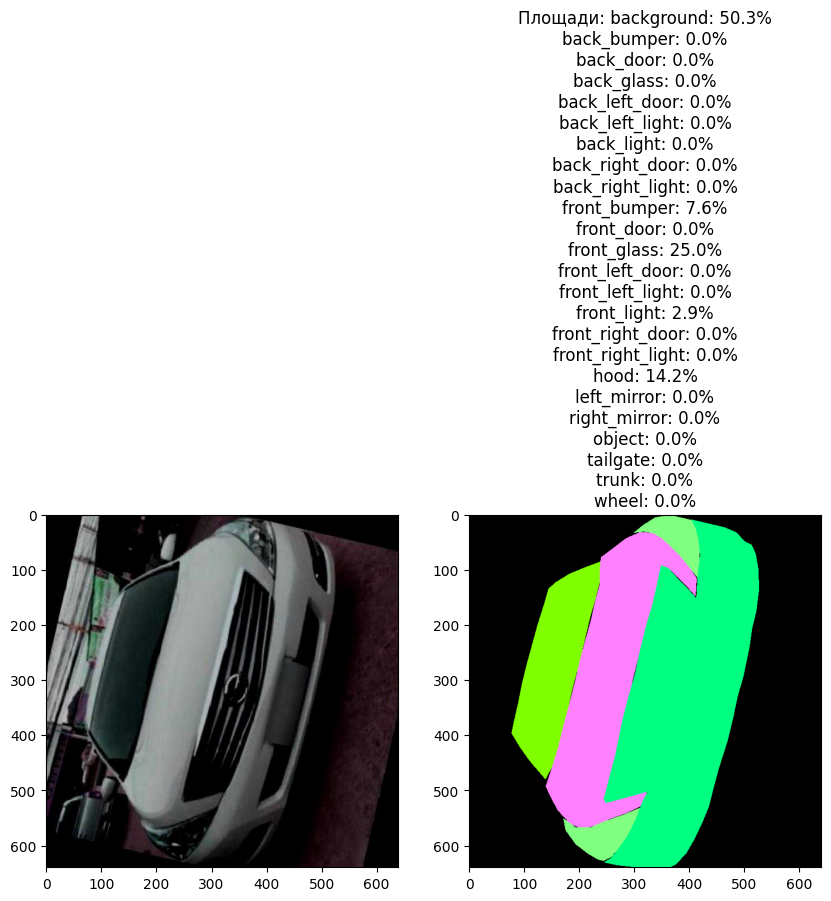

In [9]:
dataset = Dataset(X_TRAIN_DIR, Y_TRAIN_DIR)
image, mask = dataset[np.random.randint(len(dataset))]
visualize_multichennel_mask(image, mask)

In [10]:
# mask = mask.transpose(2, 0, 1)
# visual_image = visualize_with_image(image, mask, 1)
# #print(visual_image)
# cv2.imshow('2', visual_image)
# cv2.waitKey(0)
# cv2.destroyAllWindows()

# Augmentations

In [11]:
#Здесь ресайзятся изображения или самому надо???
def get_training_augmentation():
    train_transform = [

        albu.HorizontalFlip(p=0.5),

        albu.LongestMaxSize(max_size=INFER_HEIGHT, always_apply=True),
        albu.PadIfNeeded(min_height=int(INFER_HEIGHT*1.1), min_width=int(INFER_WIDTH*1.1), border_mode=2, always_apply=True),
        albu.RandomCrop(height=INFER_HEIGHT, width=INFER_WIDTH, always_apply=True),

        albu.OneOf(
            [
                albu.Sharpen(alpha=(0.1, 0.2), lightness=(0.1, 0.2), p=0.5),  # Уменьшение вероятности и уменьшение интенсивности
                albu.Blur(blur_limit=[1, 3], p=0.5),  # Уменьшение вероятности и уменьшение интенсивности
                albu.GaussNoise(var_limit=(1, 5), p=0.5),  # Уменьшение вероятности и уменьшение интенсивности
            ],
            p=0.7,  # Уменьшение вероятности применения любой аугментации
        ),
        albu.OneOf(
            [
                albu.RandomBrightnessContrast(brightness_limit=0.1, contrast_limit=0.1, p=0.5),  # Уменьшение вероятности и уменьшение интенсивности
                albu.HueSaturationValue(hue_shift_limit=5, sat_shift_limit=10, val_shift_limit=5, p=0.5),  # Уменьшение вероятности и уменьшение интенсивности
                albu.RGBShift(r_shift_limit=10, g_shift_limit=10, b_shift_limit=10, p=0.5),  # Уменьшение вероятности и уменьшение интенсивности
            ],
            p=0.7,  # Уменьшение вероятности применения любой аугментации цвета
        ),
    ]
    
    ###НЕЛЬЗЯ СТАВИТЬ FALSE!!!!!!!!!!!!!!!!!!!!!!!!!
    return albu.Compose(train_transform, is_check_shapes=True)###НЕЛЬЗЯ СТАВИТЬ FALSE!!!!!!!!!!!!!!!!!!!!!!!!!
    ###НЕЛЬЗЯ СТАВИТЬ FALSE!!!!!!!!!!!!!!!!!!!!!!!!!


def get_validation_augmentation():
    test_transform = [albu.LongestMaxSize(max_size=INFER_HEIGHT, always_apply=True),
    albu.PadIfNeeded(min_height=INFER_HEIGHT, min_width=INFER_WIDTH, border_mode=2, always_apply=True),
    albu.CenterCrop(height=INFER_HEIGHT, width=INFER_WIDTH, always_apply=True)]

    
    ###НЕЛЬЗЯ СТАВИТЬ FALSE!!!!!!!!!!!!!!!!!!!!!!!!!
    return albu.Compose(test_transform, is_check_shapes=True)###НЕЛЬЗЯ СТАВИТЬ FALSE!!!!!!!!!!!!!!!!!!!!!!!!!
    ###НЕЛЬЗЯ СТАВИТЬ FALSE!!!!!!!!!!!!!!!!!!!!!!!!!


def to_tensor(x, **kwargs):
    return x.transpose(2, 0, 1).astype('float32')


def get_preprocessing(preprocessing_fn):
    # Осуществит стартовую нормализацию данных согласно своим значениям или готовым для imagenet
    """Construct preprocessing transform
    
    Args:
        preprocessing_fn (callbale): data normalization function 
            (can be specific for each pretrained neural network)
    Return:
        transform: albumentations.Compose
    
    """
    
    _transform = [
        albu.Lambda(image=preprocessing_fn),
        albu.Lambda(image=to_tensor, mask=to_tensor),
    ]

    ###НЕЛЬЗЯ СТАВИТЬ FALSE!!!!!!!!!!!!!!!!!!!!!!!!!
    return albu.Compose(_transform, is_check_shapes=True)###НЕЛЬЗЯ СТАВИТЬ FALSE!!!!!!!!!!!!!!!!!!!!!!!!!
    ###НЕЛЬЗЯ СТАВИТЬ FALSE!!!!!!!!!!!!!!!!!!!!!!!!!

Пример аугментаций на train:

/tmp/ipykernel_2364549/699721924.py:7: UserWarning: Argument(s) 'always_apply' are not valid for transform MaxSizeTransform
  albu.LongestMaxSize(max_size=INFER_HEIGHT, always_apply=True),
/tmp/ipykernel_2364549/699721924.py:8: UserWarning: Argument(s) 'always_apply' are not valid for transform PadIfNeeded
  albu.PadIfNeeded(min_height=int(INFER_HEIGHT*1.1), min_width=int(INFER_WIDTH*1.1), border_mode=2, always_apply=True),
/tmp/ipykernel_2364549/699721924.py:9: UserWarning: Argument(s) 'always_apply' are not valid for transform RandomCrop
  albu.RandomCrop(height=INFER_HEIGHT, width=INFER_WIDTH, always_apply=True),
/home/lcz/projects/car_segmentations/SegFormer/SegFormer_venv/lib/python3.11/site-packages/albumentations/augmentations/blur/functional.py:231: UserWarning: blur_limit: Invalid kernel size range (1, 3). Values less than 3 are not allowed. Range automatically adjusted to (3, 3).
  result = _ensure_min_value(result, min_value, info.field_name)
/tmp/ipykernel_2364549/699721924

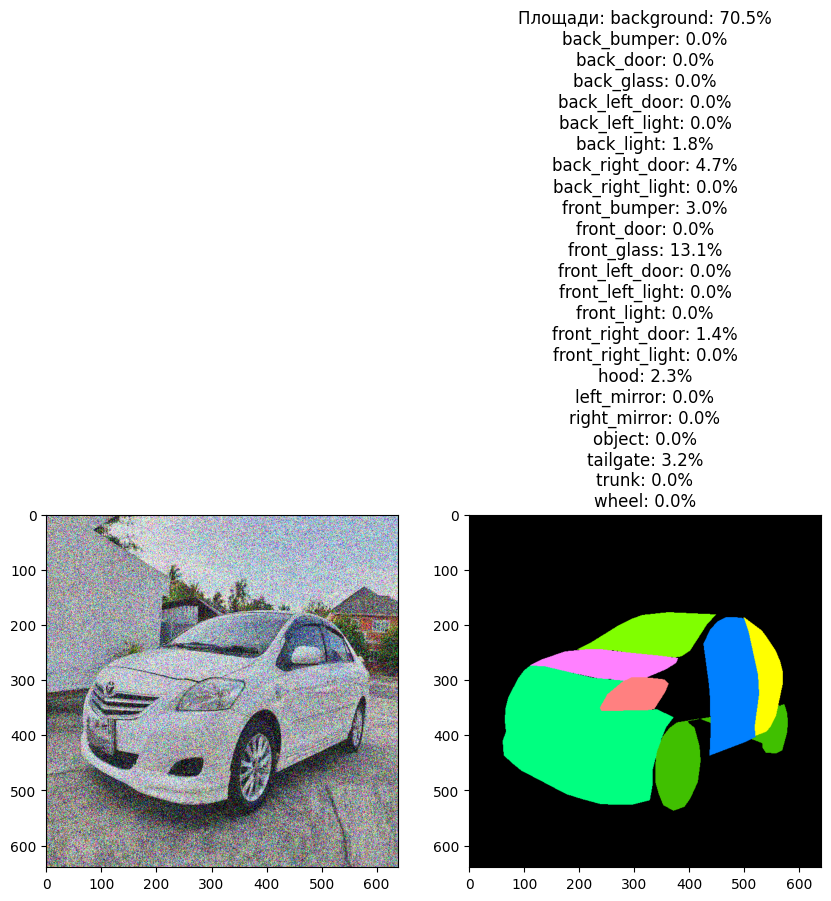

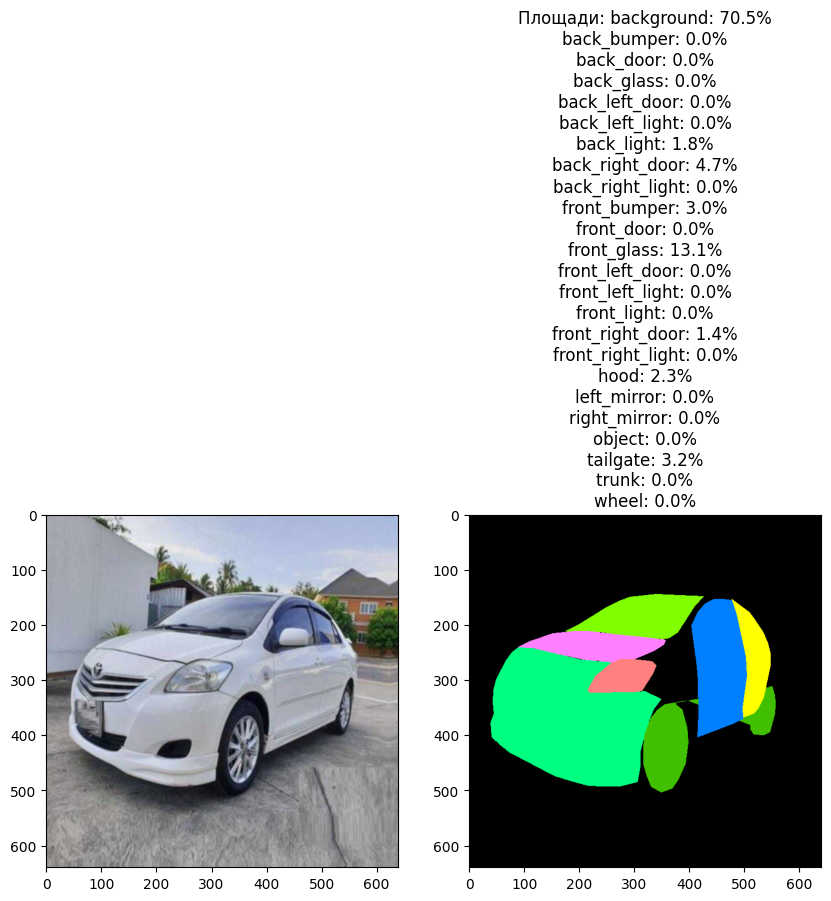

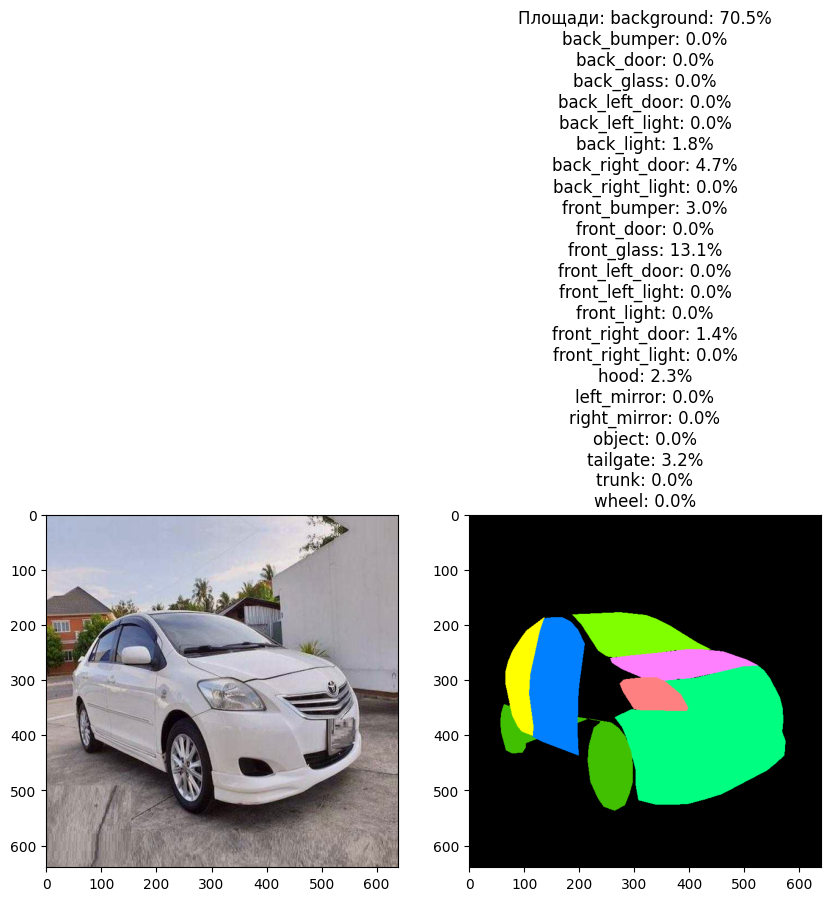

In [12]:
augmented_dataset = Dataset(
    X_TRAIN_DIR, 
    Y_TRAIN_DIR, 
    augmentation=get_training_augmentation()
)

# same image with different random transforms
indx = np.random.randint(len(augmented_dataset))

for i in range(3):
    image, mask = augmented_dataset[indx]
    visualize_multichennel_mask(image, mask)

Пример аугментаций на val:

/tmp/ipykernel_2364549/699721924.py:35: UserWarning: Argument(s) 'always_apply' are not valid for transform MaxSizeTransform
  test_transform = [albu.LongestMaxSize(max_size=INFER_HEIGHT, always_apply=True),
/tmp/ipykernel_2364549/699721924.py:36: UserWarning: Argument(s) 'always_apply' are not valid for transform PadIfNeeded
  albu.PadIfNeeded(min_height=INFER_HEIGHT, min_width=INFER_WIDTH, border_mode=2, always_apply=True),
/tmp/ipykernel_2364549/699721924.py:37: UserWarning: Argument(s) 'always_apply' are not valid for transform CenterCrop
  albu.CenterCrop(height=INFER_HEIGHT, width=INFER_WIDTH, always_apply=True)]
/tmp/ipykernel_2364549/926124796.py:69: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


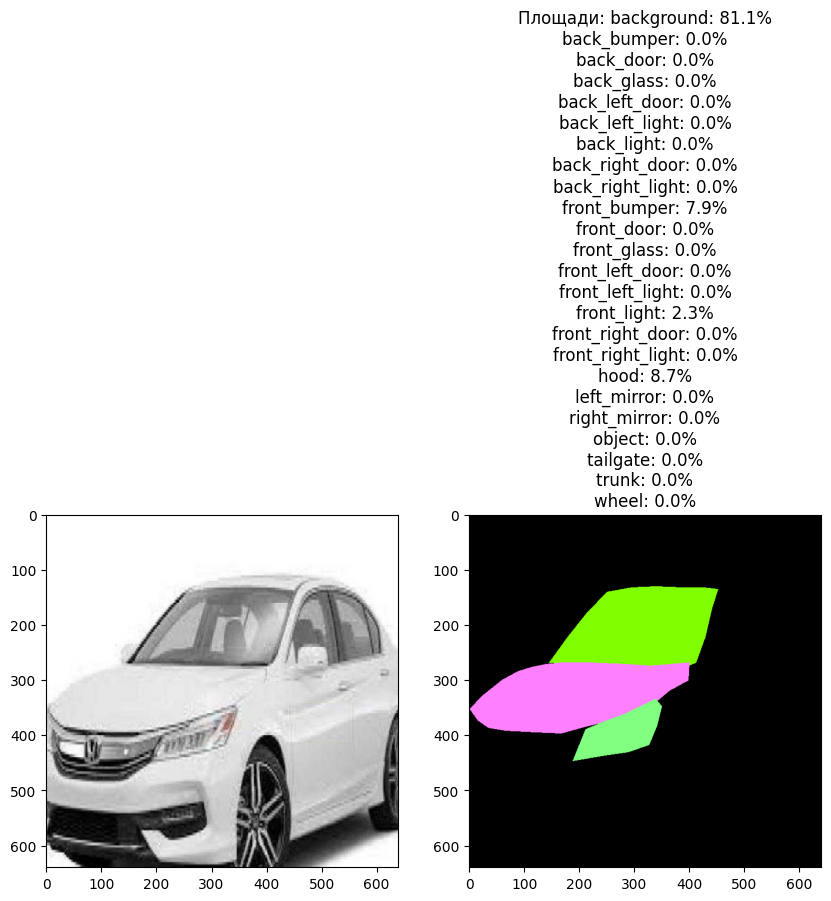

In [13]:
augmented_dataset = Dataset(
    X_VALID_DIR, 
    Y_VALID_DIR, 
    augmentation=get_validation_augmentation()
)

indx = np.random.randint(len(augmented_dataset))

image, mask = augmented_dataset[indx]
visualize_multichennel_mask(image, mask)

# Create model and train

In [14]:
num_classes = len(CLASSES)
print(num_classes, CLASSES)

#ПОПРОБУЙ ЭНКОДЕР timm-resnest50d

# create segmentation model with pretrained encoder
# model = smp.Unet(
#     encoder_name=ENCODER, 
#     encoder_weights=ENCODER_WEIGHTS, 
#     classes=len(CLASSES), 
#     activation=ACTIVATION,
# )

# model = smp.AttentionUnet(
#     encoder_name=ENCODER,
#     encoder_weights="imagenet",
#     classes=num_classes,
#     activation=ACTIVATION
# )

                                #ПОПРОБУЙ:
model = smp.DeepLabV3Plus(
    encoder_name=ENCODER,
    encoder_weights="imagenet",
    classes=num_classes,
    activation=ACTIVATION
)

# model = smp.UnetPlusPlus(
#     encoder_name=ENCODER,#'resnet18',
#     encoder_weights="imagenet",
#     classes=len(CLASSES),
#     activation=ACTIVATION
# )

24 ['background', 'back_bumper', 'back_door', 'back_glass', 'back_left_door', 'back_left_light', 'back_light', 'back_right_door', 'back_right_light', 'front_bumper', 'front_door', 'front_glass', 'front_left_door', 'front_left_light', 'front_light', 'front_right_door', 'front_right_light', 'hood', 'left_mirror', 'right_mirror', 'object', 'tailgate', 'trunk', 'wheel']


In [15]:
model

DeepLabV3Plus(
  (encoder): EfficientNetEncoder(
    (conv_stem): Conv2d(3, 72, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (bn1): BatchNormAct2d(
      72, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
      (drop): Identity()
      (act): Swish()
    )
    (blocks): Sequential(
      (0): Sequential(
        (0): DepthwiseSeparableConv(
          (conv_dw): Conv2d(72, 72, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=72, bias=False)
          (bn1): BatchNormAct2d(
            72, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
            (drop): Identity()
            (act): Swish()
          )
          (aa): Identity()
          (se): SqueezeExcite(
            (conv_reduce): Conv2d(72, 18, kernel_size=(1, 1), stride=(1, 1))
            (act1): Swish()
            (conv_expand): Conv2d(18, 72, kernel_size=(1, 1), stride=(1, 1))
            (gate): Sigmoid()
          )
          (conv_pw): Conv2d(72, 32, kernel_si

Загрузка нормализации от imagenet

In [16]:
model = torch.load("LCZ_U-Net_models/CarSeg_model_full_21.pth", weights_only=False)

In [17]:
preprocessing_fn = smp.encoders.get_preprocessing_fn(ENCODER, ENCODER_WEIGHTS)
#preprocessing_fn = lambda img, **kwargs: img.astype("float32") / 255    # -- классика деление на 255

In [18]:
preprocessing_fn

functools.partial(<function preprocess_input at 0x7f2a068507c0>, input_space='RGB', input_range=[0, 1], mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])

In [19]:
train_dataset = Dataset(
    X_TRAIN_DIR, 
    Y_TRAIN_DIR, 
    augmentation=get_training_augmentation(), 
    preprocessing=get_preprocessing(preprocessing_fn)
)

valid_dataset = Dataset(
    X_VALID_DIR, 
    Y_VALID_DIR, 
    augmentation=get_validation_augmentation(), 
    preprocessing=get_preprocessing(preprocessing_fn)
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=1, shuffle=False)

/tmp/ipykernel_2364549/699721924.py:7: UserWarning: Argument(s) 'always_apply' are not valid for transform MaxSizeTransform
  albu.LongestMaxSize(max_size=INFER_HEIGHT, always_apply=True),
/tmp/ipykernel_2364549/699721924.py:8: UserWarning: Argument(s) 'always_apply' are not valid for transform PadIfNeeded
  albu.PadIfNeeded(min_height=int(INFER_HEIGHT*1.1), min_width=int(INFER_WIDTH*1.1), border_mode=2, always_apply=True),
/tmp/ipykernel_2364549/699721924.py:9: UserWarning: Argument(s) 'always_apply' are not valid for transform RandomCrop
  albu.RandomCrop(height=INFER_HEIGHT, width=INFER_WIDTH, always_apply=True),
/tmp/ipykernel_2364549/699721924.py:15: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  albu.GaussNoise(var_limit=(1, 5), p=0.5),  # Уменьшение вероятности и уменьшение интенсивности
/tmp/ipykernel_2364549/699721924.py:35: UserWarning: Argument(s) 'always_apply' are not valid for transform MaxSizeTransform
  test_transform = [albu.LongestMaxSiz

In [20]:
metrics = [
    utils.metrics.Fscore(),
    utils.metrics.IoU()
]

optimizer = torch.optim.Adam([ 
    dict(params=model.parameters(), lr=INIT_LR),
])

In [21]:
# create epoch runners 
# it is a simple loop of iterating over dataloader`s samples
train_epoch = utils.train.TrainEpoch(
    model, 
    loss=loss, 
    metrics=metrics, 
    optimizer=optimizer,
    device=DEVICE,
    verbose=True,
)

valid_epoch = utils.train.ValidEpoch(
    model, 
    loss=loss, 
    metrics=metrics, 
    device=DEVICE,
    verbose=True,
)

In [22]:
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min", #ЕСЛИ LOSS
    factor=0.5,
    patience=3,
    threshold=1e-4,
    min_lr=1e-6,
    #verbose=True
)

scaler = GradScaler()

Обучение:

In [22]:
max_score = 0
loss_logs = {"train": [], "val": []}
metric_logs = {"train": [], "val": []}
val_metric_IOU = 0
bad_epochs = 0
last_loss = 0
total_loss_val = 0
model.train()

for i in range(0, EPOCHS):
    step = 0
    pbar = tqdm(train_loader, desc=f"Epoch {i}")
    for _, (image, label) in enumerate(pbar):
        step += 1
        label = label.to(DEVICE)
        image = image.to(DEVICE)
        optimizer.zero_grad()
        
        with autocast(device_type='cuda'):
            pred = model(image)#.to(DEVICE)
            loss_val = loss(pred, label)#.to(DEVICE)

        scaler.scale(loss_val).backward()
        total_loss_val += loss_val.item()
        scaler.step(optimizer)#.step()
        scaler.update()

        if step % 100 == 0: print(f"loss: {loss_val.item()}")
        
    total_loss_val /= len(train_loader)
    print(f"EPOCH: {i+1}; loss_val: {total_loss_val}")

    if total_loss_val > last_loss:
        bad_epochs += 1
        print(f"Метрики падают: {bad_epochs}!")
    last_loss = total_loss_val
    total_loss_val = 0

    scheduler.step(total_loss_val)
    print(f"LR: {optimizer.param_groups[0]['lr']}")
    
    if bad_epochs > 3:
        print(f'Обучение окончено на эпохе {i} из-за падения метрик')
        break
        
    if i % 1 == 0:
        torch.save(model, f"LCZ_U-Net_models/CarSeg_model_full_{i}.pth")
        print('Model saved!')
    

# for i in range(0, EPOCHS):
#     last_IOU = val_metric_IOU
#     print('\nEpoch: {}'.format(i))
#     train_logs = train_epoch.run(train_loader)
#     train_loss, train_metric, train_metric_IOU = list(train_logs.values())
#     loss_logs["train"].append(train_loss)
#     metric_logs["train"].append(train_metric_IOU)

#     valid_logs = valid_epoch.run(valid_loader)
#     val_loss, val_metric, val_metric_IOU = list(valid_logs.values())
#     loss_logs["val"].append(val_loss)
#     metric_logs["val"].append(val_metric_IOU)
    
#     # do something (save model, change lr, etc.)
#     # if max_score < valid_logs['iou_score']:
#     #     max_score = valid_logs['iou_score']
#     #     traced_model = torch.jit.script(model)
#     #     traced_model.save('My_U-Net_models/CarSeg_model_new.pt')
#     #     print('Model saved!')

#     scheduler.step(val_metric_IOU)
#     print(f"LR: {optimizer.param_groups[0]['lr']}")
    
#     if i % 1 == 0:
#         torch.save(model, f"LCZ_U-Net_models/CarSeg_model_full_{i}.pth")
#         print('Model saved!')
        
#     #print("LR:", optimizer.param_groups[0]['lr'])
#     # if i > 0 and i % LR_DECREASE_STEP == 0:
#     #     print('Decrease decoder learning rate')
#     #     optimizer.param_groups[0]['lr'] /= LR_DECREASE_COEF

#     if val_metric_IOU < last_IOU:
#         bad_epochs += 1
#         print(f'Метрики падают: {bad_epochs}!\nРазница: {last_IOU - val_metric_IOU}')

#     if bad_epochs > 2:
#         print(f'Обучение окончено на эпохе {i} из-за падения метрик')
#         break

# torch.save(model, f'LCZ_U-Net_models/CarSeg_model_full_{i}.pth')
        
# traced_model = torch.jit.script(model)
# traced_model.save('My_U-Net_models/Last_CarSeg_model.pt')

Epoch 0:   1%|▋                                                                         | 7/789 [00:08<15:06,  1.16s/it]


KeyboardInterrupt: 

Оценка обучения:

NameError: name 'loss_logs' is not defined

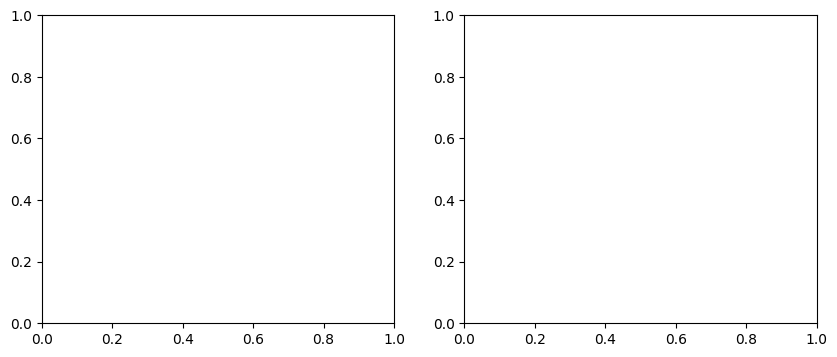

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(10,4))
axes[0].plot(loss_logs["train"], label = "train")
axes[0].plot(loss_logs["val"], label = "val")
axes[0].set_title("losses - Dice")

axes[1].plot(metric_logs["train"], label = "train")
axes[1].plot(metric_logs["val"], label = "val")
axes[1].set_title("IOU")

[ax.legend() for ax in axes];

# Test best saved model

In [24]:
#model = torch.jit.load('My_U-Net_models/CarSeg_model_new.pt')

In [25]:
model = torch.load("LCZ_U-Net_models/CarSeg_model_full_21.pth", weights_only=False)

In [26]:
def get_validation_augmentation():
    test_transform = [albu.LongestMaxSize(max_size=INFER_HEIGHT, always_apply=True),
    albu.PadIfNeeded(min_height=INFER_HEIGHT, min_width=INFER_WIDTH, border_mode=0, always_apply=True),
    albu.CenterCrop(height=INFER_HEIGHT, width=INFER_WIDTH, always_apply=True)]
    ###НЕЛЬЗЯ СТАВИТЬ FALSE!!!!!!!!!!!!!!!!!!!!!!!!!
    return albu.Compose(test_transform, is_check_shapes=True)###НЕЛЬЗЯ СТАВИТЬ FALSE!!!!!!!!!!!!!!!!!!!!!!!!!
    ###НЕЛЬЗЯ СТАВИТЬ FALSE!!!!!!!!!!!!!!!!!!!!!!!!!)

In [27]:
# оценка IoU
test_dataset = Dataset(
    X_TEST_DIR, 
    Y_TEST_DIR, 
    augmentation=get_validation_augmentation(), 
    preprocessing=get_preprocessing(preprocessing_fn)
)

test_dataloader = DataLoader(test_dataset)

test_epoch = smp.utils.train.ValidEpoch(
    model=model,#best_model,
    loss=loss,
    metrics=metrics,
    device=DEVICE,
)

logs = test_epoch.run(test_dataloader)

/tmp/ipykernel_2364549/2522298700.py:2: UserWarning: Argument(s) 'always_apply' are not valid for transform MaxSizeTransform
  test_transform = [albu.LongestMaxSize(max_size=INFER_HEIGHT, always_apply=True),
/tmp/ipykernel_2364549/2522298700.py:3: UserWarning: Argument(s) 'always_apply' are not valid for transform PadIfNeeded
  albu.PadIfNeeded(min_height=INFER_HEIGHT, min_width=INFER_WIDTH, border_mode=0, always_apply=True),
/tmp/ipykernel_2364549/2522298700.py:4: UserWarning: Argument(s) 'always_apply' are not valid for transform CenterCrop
  albu.CenterCrop(height=INFER_HEIGHT, width=INFER_WIDTH, always_apply=True)]


valid:   4%|▊                 | 12/276 [00:02<01:05,  4.03it/s, dice_loss - 0.1403, fscore - 0.8602, iou_score - 0.7712]


KeyboardInterrupt: 

# Visualize predictions

In [28]:

def _colorize_mask(mask: np.ndarray):
    mask = mask.squeeze()
    colored_mask = np.zeros((*mask.shape, 3), dtype=np.uint8)
    square_ratios = {}
    for cls_code, cls in enumerate(CLASSES):
        cls_mask = mask == cls_code
        square_ratios[cls] = cls_mask.sum() / cls_mask.size
        colored_mask += np.multiply.outer(cls_mask, COLORS_IMSHOW[cls]).astype(np.uint8)

    return colored_mask, square_ratios


def reverse_normalize(img, mean, std):
    # Invert normalization
    img = img * np.array(std) + np.array(mean)
    return img


def visualize_predicts(img: np.ndarray, mask_gt: np.ndarray, mask_pred: np.ndarray, normalized=False):
    # размер img: H, W, CHANNEL
    # размер mask_gt, mask_pred: H, W, значения - range(len(CLASSES)
    _, axes = plt.subplots(1, 3, figsize=(10, 5))
    img = img.transpose(1, 2, 0)
    if normalized:
        # Reverse the normalization to get the unnormalized image
        img = reverse_normalize(img, mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    axes[0].imshow(img)

    mask_gt, square_ratios = _colorize_mask(mask_gt)
    title = "Площади:\n"# + "\n".join([f"{cls}: {square_ratios[cls]*100:.1f}%" for cls in CLASSES])
    axes[1].imshow(mask_gt, cmap="twilight")
    axes[1].set_title(f"GT маска\n" + title)

    mask_pred, square_ratios = _colorize_mask(mask_pred)
    title = "Площади:\n"# + "\n".join([f"{cls}: {square_ratios[cls]*100:.1f}%" for cls in CLASSES])
    axes[2].imshow(mask_pred, cmap="twilight")
    axes[2].set_title(f"PRED маска\n" + title)

    plt.tight_layout()
    plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.288818357065736e-08..1.0000000236034394].


(640, 640) (3, 640, 640) (24, 640, 640)


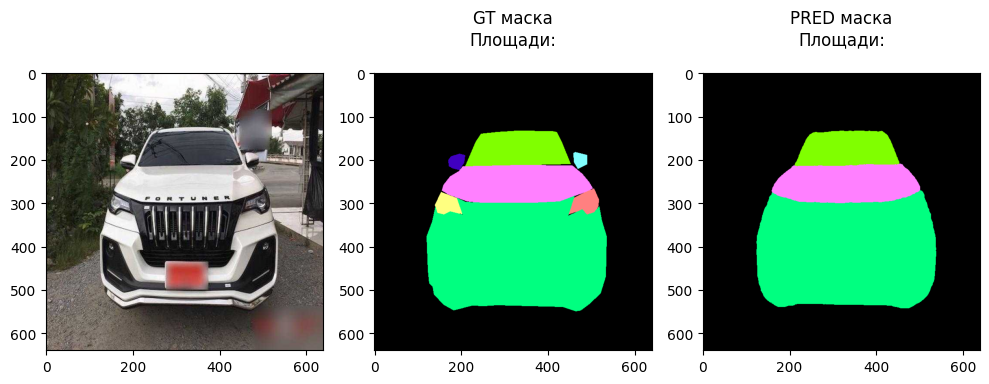

In [29]:
for i in range(1):
    n = np.random.choice(len(test_dataset))
    
    image, gt_mask = test_dataset[n]
    gt_mask = gt_mask.squeeze()
    
    x_tensor = torch.from_numpy(image).to(DEVICE).unsqueeze(0)
    #pr_mask = best_model(x_tensor)
    pr_mask = model(x_tensor)
    pr_mask = pr_mask.squeeze().cpu().detach().numpy()
    
    label_mask = np.argmax(pr_mask, axis=0)
    print(label_mask.shape, image.shape, gt_mask.shape)

    visualize_predicts(image, np.argmax(gt_mask, axis=0), label_mask, normalized=True)

---

In [30]:
def cam_vizualize(model):
    cap = cv2.VideoCapture(0)
    preprocessing_fn = smp.encoders.get_preprocessing_fn(ENCODER, ENCODER_WEIGHTS)
    
    if not cap.isOpened():
        print("Не удалось открыть веб-камеру")
        exit()
    
    while True:
        # Чтение кадра из веб-камеры
        ret, cam_frame = cap.read()
        frame = cv2.resize(cam_frame, (256, 256))
        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    
        # Если кадр успешно прочитан, ret будет True
        if not ret:
            print("Не удалось получить кадр")
            break

        frame_pr = preprocessing_fn(frame)
        frame_tensor = np.transpose(frame_pr, (2, 0, 1))
        frame_tensor =  torch.tensor(frame_tensor, dtype = torch.float32).unsqueeze(0)
        frame_tensor = frame_tensor.to(DEVICE)

        pred = model(frame_tensor)
        pred = pred.squeeze()
        pred = pred.to('cpu')
        pred*=255
        pred = pred.detach().numpy().astype(np.uint8)
        pred = np.argmax(pred,axis=0)
        pred = _colorize_mask(pred)[0]
        cv2.imshow('mask', pred)
        frame_int = frame.astype(np.uint8)
        #result = visualize_with_image(frame_int, pred, 1)
        cv2.imshow('U-Net', cam_frame)
    
        # Если нажата клавиша 'q', выход из цикла
        if cv2.waitKey(1) & 0xFF == ord('q'):
            break
    
    # Освобождение ресурсов
    cap.release()
    cv2.destroyAllWindows()

In [31]:
#cam_vizualize(model)

In [32]:
#ПОМЕНЯТЬ ЦВЕТ ЧАСТИ МАШИНЫ
test_img_path = "car_dataset/images/test/train282_jpg.rf.c8449d6a7a7f0218ff6006402e88bbf7.jpg"
#"car_dataset/images/test/car4_jpg.rf.8978131a7b03be689c244641e42e1307.jpg"

img_orig = cv2.imread(test_img_path)
img_resize = cv2.resize(img_orig, (640, 640))
preprocessing_fn = smp.encoders.get_preprocessing_fn(ENCODER, ENCODER_WEIGHTS)
#cv2.imshow('img', img_resize)
img = preprocessing_fn(img_resize)
img = img.transpose(2, 0, 1)
test_img = torch.tensor(img, dtype = torch.float32).unsqueeze(0)
test_img = test_img.to(DEVICE)
pred = model(test_img)
pred = pred.squeeze()      
pred = pred.to('cpu')
pred*=255

pred = pred.detach().numpy().astype(np.uint8)
# print(pred.shape, img_resize.shape)
#cv2.imshow('d', pred[2])#Так видит нейронка

#Для визуализации U-Net
# pred = np.argmax(pred, axis = 0)
# pred = _colorize_mask(pred)[0]

#Для замены цветов
pred = visualize_with_image(img_resize, pred, np.array([90, 50, 250]), 1)
pred = cv2.cvtColor(pred, cv2.COLOR_BGR2RGB)

pred = cv2.resize(pred, (640, 640))
# cv2.imshow('pred', pred)
# cv2.waitKey(0)
# cv2.destroyAllWindows()


In [45]:
video_path = "videos/porsche"
frames = os.listdir(video_path)
frames = sorted(frames)
i = 0
for frame in frames:
    i+=1
    frame = cv2.imread(video_path + "/" + frame)
    frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    cv2.imwrite(f"BGR_porsche/{i}.png", frame)
    # if i > 150 and i < 170:
    #     frame = cv2.imread(video_path + "/" + frame)
    #     frame = cv2.resize(frame, (INFER_WIDTH, INFER_HEIGHT))
    #     orig_img = frame
    #     #frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    #     resized_frame = frame
    #     frame = preprocessing_fn(frame)
    #     frame = frame.transpose(2, 0, 1)
    #     frame_tensor = torch.tensor(frame, dtype = torch.float32).unsqueeze(0)
    #     frame_tensor = frame_tensor.to(DEVICE)
    #     pred = model(frame_tensor)
    #     pred = pred.squeeze()      
    #     pred = pred.to('cpu')
    #     pred*=255
    #     pred = pred.detach().numpy().astype(np.uint8)
    #     pred = np.argmax(pred, axis = 0)
    #     pred = _colorize_mask(pred)[0]
    
    #     result = cv2.addWeighted(pred, 0.8, orig_img, 1, 0)
        
    #     fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    #     axes[0].imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
    #     axes[0].axis('off')

    if i == 5: break
    